# Distinction entre Variabilité des Mérites et Corrélation des Règles

## Objectif pédagogique

Ce notebook illustre une distinction très importante en **Evidence-Based Technical Analysis** :

> **La corrélation entre les règles** mesure à quel point les règles se comportent pareil.  
> **La variabilité du mérite** mesure à quel point les règles ont un vrai talent différent.

Ces deux notions peuvent sembler proches, mais elles n'ont pas le même effet sur le **biais de minage de données**.

Dans le langage EBTA :

| Facteur | Question posée | Objet mesuré | Effet sur le biais |
|---|---:|---:|---:|
| **Facteur 3 : Corrélation** | Les règles font-elles la même chose ? | Similitude des rendements observés | Corrélation faible $\Rightarrow$ biais plus élevé |
| **Facteur 5 : Variabilité du mérite** | Les règles valent-elles réellement la même chose ? | Dispersion des rendements attendus réels | Mérite très variable $\Rightarrow$ biais plus faible |

> L'erreur du trader consiste à croire que tester des règles très différentes est toujours plus scientifique.  
> En réalité, plus les règles sont décorrélées, plus le hasard reçoit d'occasions de produire un faux champion.

## Intuition EBTA

On peut décomposer la performance observée d'une règle comme suit :

$$
P_{\text{obs}, i} = \mu_i + \varepsilon_i
$$

où :

- $P_{\text{obs}, i}$ est la performance observée de la règle $i$ en **backtest** ;
- $\mu_i$ est le **mérite réel** de la règle ;
- $\varepsilon_i$ est le bruit d'échantillonnage, c'est-à-dire la chance ou la malchance.

Le data miner ne choisit pas une règle au hasard. Il choisit :

$$
\max_i(P_{\text{obs}, i})
$$

Le **biais de minage** est donc :

$$
\text{Biais} = P_{\text{obs}, \text{winner}} - \mu_{\text{winner}}
$$

Autrement dit :

> Le biais mesure la part de performance du gagnant qui vient du hasard, et non du talent réel.

## Ce que nous allons simuler

Nous allons créer un univers de règles artificielles.

Chaque règle a :

- un **mérite réel** $\mu_i$ ;
- une série de rendements bruités ;
- une corrélation plus ou moins forte avec les autres règles.

Nous allons comparer plusieurs mondes :

| Scénario | Corrélation entre règles | Mérite réel des règles | Intuition |
|---|---:|---:|---|
| A | Forte | Tous les mérites égaux à zéro | Peu de diversité comportementale |
| B | Faible | Tous les mérites égaux à zéro | Beaucoup d'occasions de fitter le bruit |
| C | Faible | Une règle a un vrai avantage | Le vrai talent peut gagner |
| D | Faible | Mérites très dispersés | Le biais diminue car le gagnant a plus de chances d'être réellement bon |

L'objectif est de voir que :

> **La décorrélation augmente les faux positifs, tandis que la dispersion du vrai mérite peut réduire la part de hasard dans le gagnant.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_rule_universe(
    n_rules=100,
    n_obs=250,
    true_merits=None,
    rho=0.0,
    noise_std=1.0
):
    """
    Simule des performances de règles de trading artificielles.
    """
    if true_merits is None:
        true_merits = np.zeros(n_rules)
    else:
        true_merits = np.asarray(true_merits)

    common_noise = np.random.normal(0, noise_std, size=(n_obs, 1))
    idiosyncratic_noise = np.random.normal(0, noise_std, size=(n_obs, n_rules))

    noise = np.sqrt(rho) * common_noise + np.sqrt(1 - rho) * idiosyncratic_noise

    returns = true_merits.reshape(1, -1) + noise
    observed_perf = returns.mean(axis=0)

    winner = np.argmax(observed_perf)
    winner_observed = observed_perf[winner]
    winner_true_merit = true_merits[winner]
    data_mining_bias = winner_observed - winner_true_merit

    return {
        "observed_perf": observed_perf,
        "true_merits": true_merits,
        "winner": winner,
        "winner_observed": winner_observed,
        "winner_true_merit": winner_true_merit,
        "data_mining_bias": data_mining_bias
    }

## Simulation 1 — Corrélation forte vs corrélation faible

Dans cette première simulation, toutes les règles sont nulles :

$$
\mu_1 = \mu_2 = \cdots = \mu_N = 0
$$

Donc, aucune règle n'a de vrai pouvoir prédictif.

La seule chose qui change est la **corrélation** entre les règles.

- Si les règles sont fortement corrélées, elles bougent presque ensemble.
- Si les règles sont faiblement corrélées, chacune offre une nouvelle chance au hasard de produire un faux gagnant.

> Quand toutes les règles sont nulles, le gagnant est forcément un gagnant par chance.

In [2]:
def monte_carlo_bias(
    n_sims=2000,
    n_rules=100,
    n_obs=250,
    rho=0.0,
    merit_mode="all_zero"
):
    biases = []
    winner_true_merits = []
    winner_observed_perfs = []

    for _ in range(n_sims):
        if merit_mode == "all_zero":
            true_merits = np.zeros(n_rules)

        elif merit_mode == "one_champion":
            true_merits = np.zeros(n_rules)
            true_merits[0] = 0.15

        elif merit_mode == "variable_merit":
            true_merits = np.random.normal(0, 0.08, size=n_rules)

        else:
            raise ValueError("merit_mode inconnu")

        result = simulate_rule_universe(
            n_rules=n_rules,
            n_obs=n_obs,
            true_merits=true_merits,
            rho=rho
        )

        biases.append(result["data_mining_bias"])
        winner_true_merits.append(result["winner_true_merit"])
        winner_observed_perfs.append(result["winner_observed"])

    return pd.DataFrame({
        "bias": biases,
        "winner_true_merit": winner_true_merits,
        "winner_observed_perf": winner_observed_perfs
    })


high_corr = monte_carlo_bias(rho=0.90, merit_mode="all_zero")
low_corr = monte_carlo_bias(rho=0.00, merit_mode="all_zero")

summary_corr = pd.DataFrame({
    "Scénario": ["Corrélation forte", "Corrélation faible"],
    "Corrélation rho": [0.90, 0.00],
    "Biais moyen": [high_corr["bias"].mean(), low_corr["bias"].mean()],
    "Performance observée moyenne du gagnant": [
        high_corr["winner_observed_perf"].mean(),
        low_corr["winner_observed_perf"].mean()
    ],
    "Mérite réel moyen du gagnant": [
        high_corr["winner_true_merit"].mean(),
        low_corr["winner_true_merit"].mean()
    ]
})

summary_corr

,Scénario,Corrélation rho,Biais moyen,Performance observée moyenne du gagnant,Mérite réel moyen du gagnant
0,Corrélation forte,0.9,0.048324,0.048324,0.0
1,Corrélation faible,0.0,0.157939,0.157939,0.0


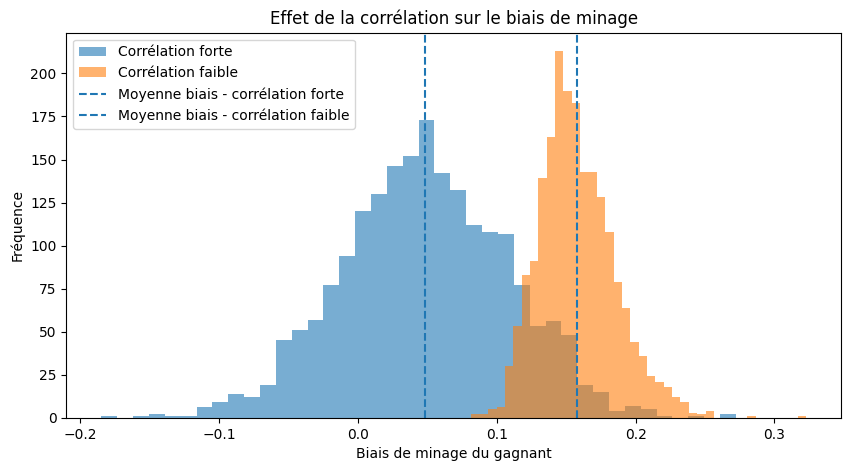

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(high_corr["bias"], bins=40, alpha=0.6, label="Corrélation forte")
plt.hist(low_corr["bias"], bins=40, alpha=0.6, label="Corrélation faible")
plt.axvline(high_corr["bias"].mean(), linestyle="--", label="Moyenne biais - corrélation forte")
plt.axvline(low_corr["bias"].mean(), linestyle="--", label="Moyenne biais - corrélation faible")
plt.title("Effet de la corrélation sur le biais de minage")
plt.xlabel("Biais de minage du gagnant")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## Lecture du graphique

Dans les deux cas, toutes les règles ont un mérite réel nul.

Donc :

$$
\mu_{\text{winner}} = 0
$$

Le biais est donc simplement :

$$
\text{Biais} = P_{\text{obs}, \text{winner}}
$$

Mais lorsque la corrélation est faible, les règles sont plus indépendantes les unes des autres.

Cela crée davantage de tickets de loterie statistiques.

> Plus les règles sont décorrélées, plus le hasard a de chances de produire un backtest exceptionnel.

## Simulation 2 — Même corrélation faible, mais mérite réel différent

Maintenant, gardons une corrélation faible.

La différence est que nous allons modifier le **mérite réel** des règles.

Nous comparons trois univers :

| Univers | Description |
|---|---|
| Tous les mérites sont nuls | Le gagnant gagne uniquement par chance |
| Une règle championne | Une règle possède un vrai avantage |
| Mérites variables | Les règles ont des talents réels différents |

Ici, le point central est :

> Si le gagnant a réellement un mérite supérieur, la performance observée contient moins de mensonge statistique.

In [4]:
all_zero = monte_carlo_bias(rho=0.0, merit_mode="all_zero")
one_champion = monte_carlo_bias(rho=0.0, merit_mode="one_champion")
variable_merit = monte_carlo_bias(rho=0.0, merit_mode="variable_merit")

summary_merit = pd.DataFrame({
    "Scénario": [
        "Tous les mérites nuls",
        "Une règle championne",
        "Mérites variables"
    ],
    "Biais moyen": [
        all_zero["bias"].mean(),
        one_champion["bias"].mean(),
        variable_merit["bias"].mean()
    ],
    "Mérite réel moyen du gagnant": [
        all_zero["winner_true_merit"].mean(),
        one_champion["winner_true_merit"].mean(),
        variable_merit["winner_true_merit"].mean()
    ],
    "Performance observée moyenne du gagnant": [
        all_zero["winner_observed_perf"].mean(),
        one_champion["winner_observed_perf"].mean(),
        variable_merit["winner_observed_perf"].mean()
    ]
})

summary_merit

,Scénario,Biais moyen,Mérite réel moyen du gagnant,Performance observée moyenne du gagnant
0,Tous les mérites nuls,0.158649,0.000000,0.158649
1,Une règle championne,0.113988,0.068625,0.182613
2,Mérites variables,0.098933,0.157686,0.256618


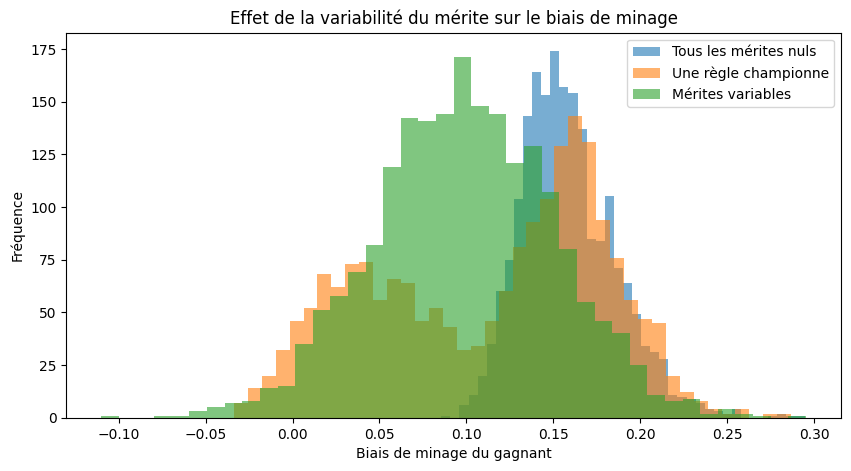

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(all_zero["bias"], bins=40, alpha=0.6, label="Tous les mérites nuls")
plt.hist(one_champion["bias"], bins=40, alpha=0.6, label="Une règle championne")
plt.hist(variable_merit["bias"], bins=40, alpha=0.6, label="Mérites variables")
plt.title("Effet de la variabilité du mérite sur le biais de minage")
plt.xlabel("Biais de minage du gagnant")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## Interprétation EBTA

Le premier scénario est le plus dangereux :

$$
\mu_i = 0 \quad \text{pour toutes les règles}
$$

Dans ce cas, la meilleure règle observée est seulement :

$$
\max_i(\varepsilon_i)
$$

Elle gagne parce qu'elle a reçu le meilleur bruit.

Mais si une règle a un vrai mérite supérieur :

$$
\mu_{\text{champion}} > \mu_{\text{autres}}
$$

alors le gagnant observé peut gagner pour une meilleure raison :

$$
P_{\text{obs}, \text{winner}} = \mu_{\text{winner}} + \varepsilon_{\text{winner}}
$$

Le gagnant contient encore du bruit, mais une plus grande partie de sa performance vient du mérite réel.

> Une grande variabilité de mérite réduit le biais parce que le gagnant est moins probablement un pur accident.

## Comparaison mentale : deux dimensions différentes

### Dimension 1 — Corrélation des règles

La corrélation répond à la question :

> Est-ce que les règles produisent des rendements semblables ?

Exemple :

- EMA 20/50 ;
- EMA 21/50 ;
- EMA 22/50.

Ces règles sont probablement très corrélées.

Statistiquement, tester ces trois règles n'est pas équivalent à tester trois idées totalement indépendantes.

### Dimension 2 — Mérite réel des règles

Le mérite répond à la question :

> Est-ce qu'une règle possède vraiment un meilleur rendement attendu ?

Exemple :

- une règle sans logique économique ;
- une règle basée sur une anomalie structurelle ;
- une règle exploitant une inefficience réellement robuste.

Ici, les règles peuvent avoir des niveaux de talent très différents.

## Exemple trading concret

Imagine que tu testes 100 stratégies sur le Gold.

### Cas 1 — Règles très proches

Tu testes :

- breakout 20 périodes ;
- breakout 21 périodes ;
- breakout 22 périodes ;
- breakout 23 périodes.

Ces règles sont différentes en apparence, mais elles prennent souvent les mêmes trades.

Donc leur corrélation est forte.

Résultat :

> Le biais de minage augmente moins vite, car tu ne fais pas réellement 100 paris indépendants contre le hasard.

### Cas 2 — Règles radicalement différentes

Tu testes :

- RSI ;
- MACD ;
- VWAP ;
- order flow ;
- Bollinger Bands ;
- breakout ;
- mean reversion ;
- patterns chandeliers ;
- volume profile.

Ces règles sont beaucoup plus décorrélées.

Résultat :

> Le biais de minage augmente fortement, car chaque famille de règles offre au hasard une nouvelle occasion de produire une illusion.

### Cas 3 — Une règle a une vraie raison d'être supérieure

Si une règle repose sur une logique robuste, par exemple une inefficience microstructurelle documentée, alors son mérite réel peut être supérieur.

Résultat :

> Le biais peut diminuer parce que le gagnant n'est pas seulement le produit d'un bruit favorable.

## L'Eurêka final

> **La corrélation concerne la diversité des comportements.**  
> **Le mérite concerne la diversité du talent réel.**

Ces deux dimensions ne disent pas la même chose.

Une règle peut être :

| Cas | Corrélation avec les autres | Mérite réel | Lecture |
|---|---:|---:|---|
| Règle clonée | Forte | Faible | Peu de nouveau signal |
| Règle originale mais nulle | Faible | Faible | Très dangereuse pour le data mining |
| Règle originale et robuste | Faible | Fort | Candidat sérieux |
| Règle proche mais supérieure | Forte | Fort | Peut être utile malgré la similarité |

La conclusion opérationnelle est simple :

> Tester beaucoup de règles différentes augmente le risque de faux champion, sauf si l'univers testé contient réellement des règles de mérite supérieur.

## Checklist EBTA pour ton research process

Avant de lancer une grande campagne de **backtests**, pose-toi ces questions :

| Question | Facteur concerné | Risque si ignoré |
|---|---:|---|
| Mes règles sont-elles presque identiques ? | Corrélation | Surestimer le nombre réel de tests |
| Mes règles sont-elles très différentes ? | Corrélation | Sous-estimer le biais de minage |
| Ai-je une raison théorique de croire qu'une règle est meilleure ? | Mérite | Confondre bruit et avantage réel |
| Est-ce que mon gagnant reste bon hors échantillon ? | Validation | Sélectionner un faux positif |
| Ai-je ajusté ma p-value pour comparaisons multiples ? | White's Reality Check | Conclure trop vite à un edge |

> En EBTA, la question n'est pas seulement : “Quelle règle gagne le backtest ?”  
> La vraie question est : “Quelle part de sa victoire vient du mérite, et quelle part vient du hasard ?”

## Annexe — Source originale collée

Le texte ci-dessous est la source fournie pour générer ce notebook pédagogique.


### **DISTINCTION ENTRE VARIABILITÉ DES MÉRITES ET VARIABILITÉ (CORRÉLATION) DES RÈGLES**

Non, selon David Aronson, la **variabilité des mérites** (Facteur 5) et ce que l'on pourrait appeler la variabilité des règles (définie techniquement comme la **corrélation**, Facteur 3) sont deux facteurs distincts et indépendants qui influencent l'ampleur du biais de minage de données,,.

#### **Idées clés :**
*   **Nature différente :** La variabilité du mérite concerne le **talent réel** (rendement attendu) des règles, tandis que la corrélation concerne la **similitude des comportements** (rendements observés),.
*   **Facteur 3 (Corrélation) :** Mesure à quel point les signaux de deux règles se ressemblent. Moins elles sont corrélées (plus elles sont "variables" ou "diverses"), plus le biais de minage augmente,.
*   **Facteur 5 (Mérite) :** Mesure la dispersion du pouvoir prédictif réel. Plus le mérite est variable (plus il y a une règle "géniale" parmi des règles nulles), plus le biais de minage diminue,.
*   **Effets opposés sur le biais :** Une grande diversité comportementale (corrélation faible) **augmente** le mensonge statistique, alors qu'une grande diversité de talent (mérite variable) le **réduit**,.

#### **Référence :**
*The Five Factors Defined*, Chapitre 6, pages 288, 301 et 306.

#### **Citation Directe :**
« Factor 3: Correlation among rule returns: This refers to the degree to which the performance histories of the rules tested are correlated with each other. [...] Factor 5: Variation in expected returns among the rules: This refers to the variation in true merit (expected return) among the rules back tested. » (Page 288).

---

#### **Vision Macro :**
L'enjeu est de comprendre la structure de l'univers de recherche du trader. Aronson distingue **ce que la règle fait** (ses positions long/short qui créent de la corrélation) de **ce que la règle vaut** (son pouvoir prédictif réel). Pour un data miner, tester 1 000 règles qui font toutes la même chose est peu risqué mais peu productif. Tester 1 000 règles radicalement différentes augmente les chances de trouver "l'or véritable", mais augmente encore plus massivement le risque de choisir du "métal des fous" (biais de minage),.

---

#### **Vision Micro :**

1.  **Variabilité comportementale (Corrélation - Facteur 3) :**
    *   Si vous testez des règles très proches (ex: moyennes mobiles 20 vs 21), elles sont fortement corrélées. Statistiquement, c'est comme si vous ne faisiez qu'un seul test. Le biais est faible car le hasard a peu d'opportunités de créer une anomalie isolée,.
    *   Si les règles sont décorrélées (variabilité élevée des signaux), chaque règle offre une nouvelle chance au hasard de "fitter" le bruit du marché. Le biais est alors maximal,.

2.  **Variabilité du talent (Mérite - Facteur 5) :**
    *   Si toutes les règles ont le même mérite (ex: toutes sont nulles), le gagnant ne gagne que par chance. Le biais est alors égal à la totalité de la performance observée.
    *   S'il existe une forte variabilité du mérite (ex: une règle est excellente et les autres nulles), le talent de la règle supérieure "perce le brouillard". Elle gagne car elle est bonne, pas seulement parce qu'elle est chanceuse. Le biais (la part de chance ajoutée au mérite) est alors réduit,.

---

#### **Résumé Simplifié :**
Imaginez un concours de tir à l'arc.
*   **La corrélation (Facteur 3)**, c'est la direction des tirs : si tout le monde tire au même endroit, on n'apprend rien de nouveau. Si tout le monde tire dans des directions opposées (variabilité élevée), on finit par toucher le centre par pur hasard.
*   **La variabilité du mérite (Facteur 5)**, c'est le niveau des archers : si tout le monde est nul, le gagnant est un chanceux (gros biais). Si un champion est dans le lot, il gagne par talent (faible biais).

---

#### **Actions Concrètes :**
*   **Ne confondez pas diversité et sécurité :** Tester des indicateurs très variés (RSI + MACD + Volume) augmente votre biais de minage plus qu'optimiser un seul indicateur,.
*   **Cherchez l'asymétrie de mérite :** Le minage de données est plus fiable si vous avez de bonnes raisons théoriques de penser qu'une des règles de votre univers est largement supérieure aux autres,.
*   **Ajustez le White's Reality Check :** Cet outil est indispensable car il prend en compte la **corrélation** réelle entre vos règles pour ajuster la p-value,.

---

#### **À retenir absolument :**
*   **Facteur 3 (Corrélation)** = Similitude des **signaux**.
*   **Facteur 5 (Mérite)** = Similitude du **talent réel**.
*   Tester des règles **décorrélées** (très différentes) **augmente** le risque de mirage.
*   Avoir une règle de **mérite supérieur** dans son univers **diminue** le biais.
*   Ce sont deux leviers mathématiquement distincts dans l'analyse EBTA.

J'ai terminé l'analyse de la distinction entre variabilité des mérites et corrélation des règles selon le protocole EBTA.